# Notebook 3 : Linear Algebra and traning momdels

---


## Learning objectives
- Linear Regression
- 1-D Gradient Descents
- Loss functions
- Linear algebra review
- Supervised learning overview
- How to train a model (training/test)

## Libraries

In [18]:
#Libraries
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Linear Regression with residuals

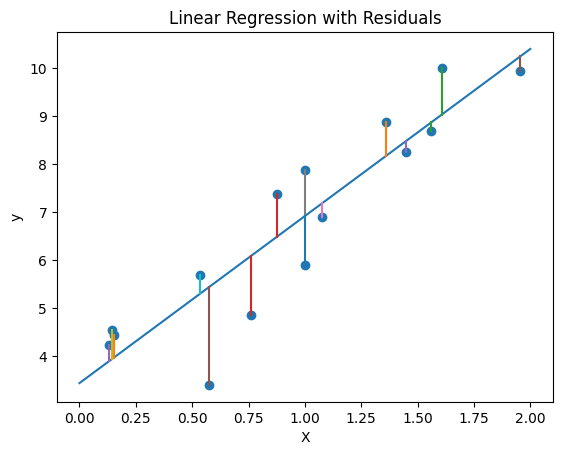

R^2 score : 0.8341299898040686


In [20]:
# New random dataset (fewer points)
np.random.seed(7)
X = 2 * np.random.rand(15, 1)
y = 4 + 3 * X + np.random.randn(15, 1)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predictions for line
X_line = np.linspace(0, 2, 100).reshape(-1, 1)
y_line = model.predict(X_line)

# Predictions for original points (for residuals)
y_pred_points = model.predict(X)

# Plot scatter
plt.scatter(X, y)

# Plot regression line
plt.plot(X_line, y_line)

# Draw residual lines (vertical distance)
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], y_pred_points[i]])

# Labels and title
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression with Residuals")

plt.show()

print(f'R^2 score : {r2_score(y,y_pred_points)}')

## Linear Regression with more data points

```
model = LinearRegression()
model.fit(X, y)
```

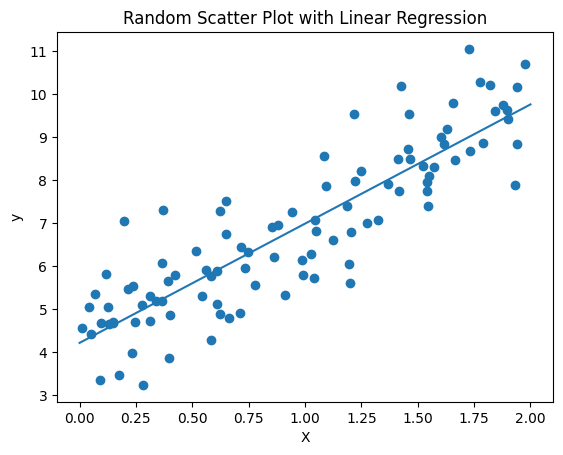

Intercept: 4.22
Slope: 2.77


In [15]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate random data
X = 2 * np.random.rand(100, 1)  # 100 points between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1)  # linear relation with noise

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Predict values for the regression line
X_new = np.linspace(0, 2, 100).reshape(-1, 1) #creates the line -- almost like a parameterization
y_pred = model.predict(X_new)

# Plot the scatter points
plt.scatter(X, y)

# Plot the regression line
plt.plot(X_new, y_pred)

# Labels and title
plt.xlabel("X")
plt.ylabel("y")
plt.title("Random Scatter Plot with Linear Regression")

# Show plot
plt.show()

# Print model parameters
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"Slope: {model.coef_[0][0]:.2f}")

## Gradient Descent Visual

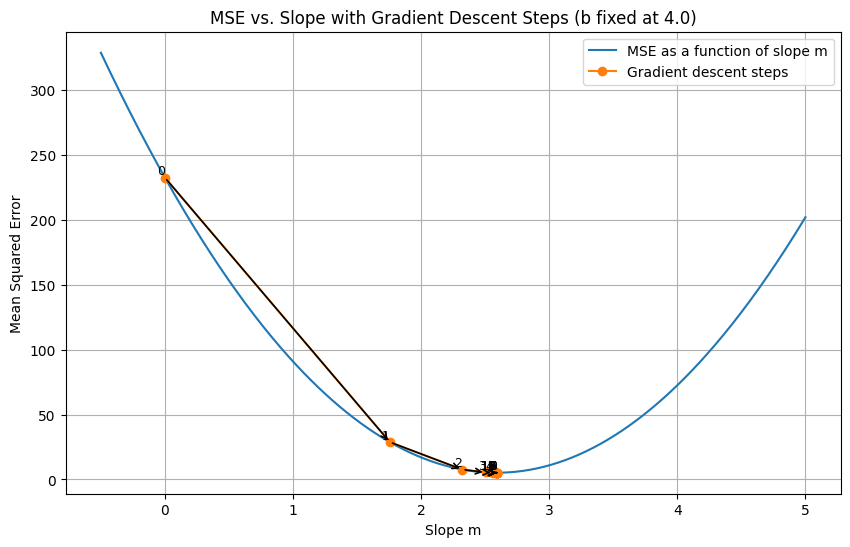

Step  0: m = 0.0000, MSE = 232.6515
Step  1: m = 1.7564, MSE = 28.7517
Step  2: m = 2.3217, MSE = 7.6316
Step  3: m = 2.5037, MSE = 5.4440
Step  4: m = 2.5622, MSE = 5.2174
Step  5: m = 2.5811, MSE = 5.1939
Step  6: m = 2.5871, MSE = 5.1915
Step  7: m = 2.5891, MSE = 5.1913
Step  8: m = 2.5897, MSE = 5.1912
Step  9: m = 2.5899, MSE = 5.1912
Step 10: m = 2.5900, MSE = 5.1912
Step 11: m = 2.5900, MSE = 5.1912
Step 12: m = 2.5900, MSE = 5.1912


In [24]:
# -----------------------------
# Generate data
# -----------------------------
np.random.seed(0)
x = np.linspace(0, 10, 30)
true_b = 4.0
true_m = 2.5
y = true_b + true_m * x + np.random.randn(len(x)) * 2

# -----------------------------
# Fix intercept and optimize only slope
# -----------------------------
b_fixed = 4.0

def mse(m, b, x, y):
    return np.mean((b + m * x - y) ** 2)

def grad_m(m, b, x, y):
    n = len(x)
    return (2 / n) * np.sum((b + m * x - y) * x)

# -----------------------------
# Gradient descent on m only
# -----------------------------
m = 0.0
learning_rate = 0.01
num_steps = 12

m_history = [m]
mse_history = [mse(m, b_fixed, x, y)]

for _ in range(num_steps):
    m = m - learning_rate * grad_m(m, b_fixed, x, y)
    m_history.append(m)
    mse_history.append(mse(m, b_fixed, x, y))

# -----------------------------
# Smooth MSE curve
# -----------------------------
m_vals = np.linspace(-0.5, 5.0, 400)
mse_vals = [mse(mv, b_fixed, x, y) for mv in m_vals]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(m_vals, mse_vals, label="MSE as a function of slope m")
plt.plot(m_history, mse_history, 'o-', label="Gradient descent steps")

# Number each step
for i, (m_i, j_i) in enumerate(zip(m_history, mse_history)):
    plt.text(m_i, j_i, str(i), fontsize=9, ha='right', va='bottom')

# Draw arrows between steps
for i in range(len(m_history) - 1):
    plt.annotate(
        "",
        xy=(m_history[i + 1], mse_history[i + 1]),
        xytext=(m_history[i], mse_history[i]),
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )

plt.xlabel("Slope m")
plt.ylabel("Mean Squared Error")
plt.title(f"MSE vs. Slope with Gradient Descent Steps (b fixed at {b_fixed})")
plt.legend()
plt.grid(True)
plt.show()

# Print step-by-step values
for i in range(len(m_history)):
    print(f"Step {i:2d}: m = {m_history[i]:.4f}, MSE = {mse_history[i]:.4f}")

## Multiple Linear Regression

```
model = LinearRegression()
model.fit(X, y)
```

Intercept: 2.772272264101702
Coefficients: [ 4.33866677 -1.64505397]


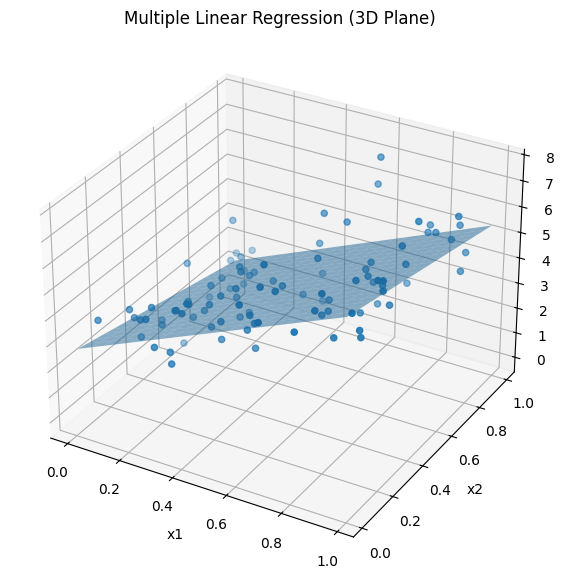

In [17]:
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Generate synthetic data
# -----------------------------
np.random.seed(42)
n_samples = 100

X = np.random.rand(n_samples, 2)
x1 = X[:, 0]
x2 = X[:, 1]

# True relationship
b_true = 3
w1_true = 4
w2_true = -2

y = b_true + w1_true * x1 + w2_true * x2 + np.random.randn(n_samples)

# -----------------------------
# Fit model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# -----------------------------
# Create grid for plane
# -----------------------------
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 20),
    np.linspace(x2.min(), x2.max(), 20)
)

# Predict on grid
X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
y_grid = model.predict(X_grid).reshape(x1_grid.shape)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter data
ax.scatter(x1, x2, y)

# Regression plane
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)

# Labels
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Multiple Linear Regression (3D Plane)")

plt.show()

In [47]:
import yfinance as yf
import datetime

# 1. Define time frame for the stock data
start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2026, 5, 1)

# 2. Fetch data
# This returns the exact same Pandas DataFrame format
df_MSFT = yf.download('MSFT', start=start, end=end)

# Confidence Check : Look at the data
df_MSFT


df_MSFT_plot = df_MSFT.reset_index()
# Flatten multi-level columns from yfinance output
df_MSFT_plot.columns = ['_'.join(col).strip() if isinstance(col, tuple) and col[1] else col[0] for col in df_MSFT_plot.columns.values]

#Notice this is tuple
print(df_MSFT.columns)

#Notice this is an arrary of names
print(df_MSFT_plot.columns)

#Creating time series line plot
fig_time_ser = px.line(df_MSFT_plot, x='Date', y='Close_MSFT')

#Visualizing time series chart
fig_time_ser

X = df_MSFT_plot['Date']
y = df_MSFT_plot['Close_MSFT']

model = LinearRegression()
X


/tmp/ipykernel_4536/27424716.py:10: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])
Index(['Date', 'Close_MSFT', 'High_MSFT', 'Low_MSFT', 'Open_MSFT',
       'Volume_MSFT'],
      dtype='object')


,Date
0,2020-01-02
1,2020-01-03
2,2020-01-06
3,2020-01-07
4,2020-01-08
...,...
1585,2026-04-24
1586,2026-04-27
1587,2026-04-28
1588,2026-04-29


# Resources

1. [Introduction to Statistical Thinking](https://www.statlearning.com/) - Comes highly recommended by Mario